# 06 · Web scraping poli : books.toscrape.com

Quand une source n'offre **ni API ni fichier**, il reste une solution : lire ses pages web avec un programme, comme le ferait un navigateur. C'est le **web scraping** (littéralement « grattage » de pages). C'est la méthode la plus **fragile** et la plus **délicate** sur le plan juridique : on l'utilise **en dernier recours**, et **poliment**.

> 🎯 **Cas d'usage**
>
> Une librairie en ligne veut **surveiller les prix d'un concurrent** pour ajuster les siens. Ce concurrent (fictif) est **books.toscrape.com**, un site « bac à sable » créé exprès pour s'entraîner au scraping : 1 000 livres répartis sur 50 pages.
>
> Le site ne propose **ni API ni fichier à télécharger** : il faut lire ses pages.
>
> Votre mission : constituer le **catalogue complet** (titre, prix, note, disponibilité, adresse de la fiche), proprement et poliment, l'enregistrer en CSV et en Parquet, puis répondre aux questions du responsable : les livres bien notés sont-ils plus chers ? Quels sont les livres les plus chers ?

**Ce que vous allez apprendre**
- vérifier, **avant** de scraper, que c'est la bonne méthode et qu'on en a le droit (règle d'or, `robots.txt`, CGU, éthique) ;
- télécharger une page avec `requests` et corriger un problème d'**encodage** (le fameux « Â£ ») ;
- lire la structure d'une page **HTML** et viser les bons éléments avec des **sélecteurs CSS** ;
- extraire des données avec **BeautifulSoup** et les convertir (texte → nombre) ;
- parcourir **toutes les pages** (pagination) en restant poli : User-Agent, pauses, **cache** sur disque ;
- contrôler le résultat et détecter que le site a changé (la fragilité du scraping).

**Durée indicative** : 20 minutes (+ 15 minutes si vous faites tous les exercices).

**Prérequis**
- Python de base et pandas (un `DataFrame`, filtrer, trier) ;
- le notebook 05 (requêtes HTTP, codes de réponse, User-Agent, `timeout`) est un bon échauffement ;
- une connexion Internet et un navigateur web (pour l'astuce « Inspecter »).

**Mode d'emploi** : exécutez les cellules dans l'ordre (Maj + Entrée). La collecte complète (section 7) prend 1 à 2 minutes la première fois (selon votre connexion), puis quelques secondes grâce au cache.

## 1. Préparer l'environnement

On importe les bibliothèques :
- `requests` télécharge les pages web (comme au notebook 05) ;
- `BeautifulSoup` (paquet `beautifulsoup4`) lit le HTML et permet d'y **chercher des éléments** ;
- `urljoin` transforme un lien **relatif** (`page-2.html`) en adresse **complète** (`https://…/page-2.html`) ;
- `time` sert à faire des **pauses** et à mesurer des durées ;
- `date` et `Path` servent à dater et à ranger les fichiers sur le disque ;
- `pandas` et `matplotlib` rangent et dessinent les résultats.

In [1]:
import time
from datetime import date
from pathlib import Path
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import pandas as pd
import requests
from bs4 import BeautifulSoup

On range les fichiers comme dans le cours sur le **data lake** :
- les pages HTML **brutes**, telles que le site les a envoyées, dans `data/raw/scraping/` (couche *bronze*). Ce dossier sert aussi de **cache** (section 7) ;
- le catalogue **propre** dans `data/processed/` (couche *silver*).

Le dossier des pages brutes porte la **date du jour** : une veille de prix, c'est une « photo » du site par jour.

In [2]:
DOSSIER_DATA = Path("../data")
AUJOURDHUI = date.today().isoformat()            # ex. '2026-10-07'

# Pages HTML brutes du jour (= notre cache)
DOSSIER_CACHE = DOSSIER_DATA / "raw" / "scraping" / "books" / AUJOURDHUI
DOSSIER_PROPRE = DOSSIER_DATA / "processed"
DOSSIER_CACHE.mkdir(parents=True, exist_ok=True)
DOSSIER_PROPRE.mkdir(parents=True, exist_ok=True)
print("Pages brutes (cache) :", DOSSIER_CACHE)
print("Résultats propres    :", DOSSIER_PROPRE)

Pages brutes (cache) : ../data/raw/scraping/books/2026-10-07
Résultats propres    : ../data/processed


Enfin, les **réglages de politesse**, regroupés en haut pour être faciles à modifier :
- le **User-Agent** : la « carte de visite » de notre programme, envoyée avec chaque requête (en production, on y ajoute une adresse e-mail de contact ; pas d'accents dans un en-tête HTTP) ;
- le **délai maximal** (*timeout*) d'attente d'une réponse ;
- la **pause** entre deux pages : on ne mitraille pas le serveur ;
- le **nombre maximal de pages** à lire : 50 = tout le site. Mettez 3 pour faire un essai rapide.

In [3]:
URL_SITE = "https://books.toscrape.com/"
URL_DEPART = "https://books.toscrape.com/catalogue/page-1.html"

EN_TETES = {"User-Agent": "cours-AMA (TP Sources de donnees ; usage pedagogique)"}
DELAI_MAX = 30          # secondes d'attente maximale par requête
PAUSE_SECONDES = 0.5    # pause après chaque page téléchargée
MAX_PAGES = 50          # 50 = tout le site ; 3 pour un essai rapide

## 2. Avant de scraper : est-ce la bonne méthode, et a-t-on le droit ?

### 2.1 La règle d'or

> 💡 **Règle d'or du cours** : une **API**, sinon un **fichier officiel**, et le **scraping en dernier recours**.

| Méthode | Avantages | Inconvénients |
|---|---|---|
| **API** | données structurées (JSON), contrat stable, quotas clairs | il faut parfois une clé |
| **Fichier officiel** (CSV, Parquet…) | complet, daté, souvent avec une licence | mis à jour moins souvent |
| **Scraping** | possible même sans API ni fichier | **fragile** (le HTML change sans prévenir), charge le serveur, droit à vérifier |

Avant de scraper un vrai site, cherchez donc d'abord une API (souvent cachée dans le pied de page : « Développeurs », « API », « Open data ») ou un fichier d'export. Ici, books.toscrape.com n'a ni l'un ni l'autre : le scraping est justifié.

### 2.2 Le fichier `robots.txt`

Beaucoup de sites publient à leur racine un fichier texte, `robots.txt`, qui dit aux **robots** (les programmes qui parcourent le web) ce qu'ils peuvent visiter. Il ressemble à ceci :

```text
User-agent: *          # règles pour tous les robots
Disallow: /panier/     # ne pas visiter ces pages
Disallow: /compte/
Crawl-delay: 2         # attendre 2 secondes entre deux pages (directive non officielle)
```

C'est une **convention** (norme RFC 9309), pas un verrou : rien n'empêche techniquement de l'ignorer, mais un robot poli la respecte toujours. Allons lire celui de notre site.

In [4]:
reponse_robots = requests.get(URL_SITE + "robots.txt", headers=EN_TETES, timeout=DELAI_MAX)
print("Code HTTP de robots.txt :", reponse_robots.status_code)

if reponse_robots.status_code == 200:
    print(reponse_robots.text)
else:
    print("Pas de robots.txt publié : le site ne fixe aucune règle aux robots.")

Code HTTP de robots.txt : 404
Pas de robots.txt publié : le site ne fixe aucune règle aux robots.


**404** = « page introuvable » : ce site ne publie **pas** de `robots.txt`. D'après la norme, un robot peut alors visiter toutes les pages.

> ⚠️ « Pas de règle » ne veut pas dire « tout est permis ». Les **conditions d'utilisation** et la **loi** s'appliquent toujours, et la **politesse** aussi : nous allons nous présenter (User-Agent), faire des pauses, garder une copie des pages pour ne jamais les télécharger deux fois, et ne lire que les pages utiles.

### 2.3 Les CGU, l'éthique et le droit

Les **CGU** (conditions générales d'utilisation) d'un site interdisent parfois la collecte automatique : dans ce cas, on ne scrape pas, on demande une autorisation (ou un accès officiel). books.toscrape.com n'a pas de CGU, mais il affiche un bandeau très clair (nous l'extrairons à la section 5) : c'est un site de **démonstration pour le web scraping**, dont les prix et les notes sont **tirés au hasard**.

Avant toute collecte, reprenez les questions du slide « stratégie et éthique » du cours :

| Question | Pour notre mission |
|---|---|
| **Finalité** : quelle décision cette donnée va-t-elle servir ? | ajuster nos prix face au concurrent |
| **Minimisation** : seulement ce qui sert, pas « au cas où » | titre, prix, note, disponibilité, adresse de la fiche. **Pas** d'images, **pas** d'avis clients |
| **Données personnelles** (*PII*, informations qui identifient une personne) ? | aucune ici. Des avis signés, des noms de vendeurs… le seraient : le **RGPD** (règlement européen sur la protection des données) et les lois nationales (au Bénin, le Code du numérique, contrôlé par l'APDP) s'appliquent **même si ces données sont publiques** |
| **Charge** pour le site | 50 pages, une pause d'une demi-seconde après chacune, et chaque page téléchargée une seule fois (cache) |

> 💡 **À débattre** : scraper les **prix** d'un concurrent (des informations commerciales publiques) est en général moins délicat que scraper ses **avis clients** (textes protégés par le droit d'auteur, souvent signés par des personnes). En Europe, copier une **partie substantielle** d'une base de données protégée peut aussi être interdit. Dans un vrai projet : CGU, juriste, et une collecte minimale.

## 3. Récupérer une page

Une page web n'est qu'un **fichier texte** au format HTML, que le serveur envoie quand on le demande. On la télécharge avec `requests.get`, exactement comme une réponse d'API au notebook 05, avec notre User-Agent et un délai maximal.

In [5]:
reponse = requests.get(URL_DEPART, headers=EN_TETES, timeout=DELAI_MAX)

print("Code HTTP             :", reponse.status_code)
print("Type de contenu       :", reponse.headers["Content-Type"])
print("Dernière modification :", reponse.headers.get("Last-Modified"))
print("Taille                :", len(reponse.content), "octets")

Code HTTP             : 200
Type de contenu       : text/html
Dernière modification : Wed, 08 Feb 2023 21:02:32 GMT
Taille                : 50469 octets


- **200** : tout va bien.
- `text/html` : c'est une page HTML (et non du JSON comme avec une API).
- L'en-tête `Last-Modified` indique que la page n'a pas changé depuis **2023** : ce site d'entraînement est figé. Chez un vrai concurrent, les prix bougeraient d'un jour à l'autre.

### Le piège de l'encodage : « Â£ »

Cherchons le premier prix dans le texte de la page. Il se trouve juste après `class="price_color"` (nous verrons pourquoi à la section 4).

In [6]:
print("Encodage choisi par requests :", reponse.encoding)

position = reponse.text.find('class="price_color"')
print("Extrait du texte :", reponse.text[position : position + 35])

Encodage choisi par requests : ISO-8859-1
Extrait du texte : class="price_color">Â£51.77</p>
   


Le prix s'affiche « **Â£51.77** » au lieu de « **£51.77** » ! Que s'est-il passé ?

- Un ordinateur stocke du texte sous forme d'**octets**. L'**encodage** est la table de correspondance entre caractères et octets. Le plus courant aujourd'hui est **UTF-8**.
- Le serveur a répondu `Content-Type: text/html` **sans préciser l'encodage**. Dans ce cas, `requests` applique une ancienne règle du protocole HTTP : par défaut, un texte est en **ISO-8859-1** (aussi appelé Latin-1).
- Or la page est écrite en UTF-8, où le symbole « £ » occupe **deux** octets. Lus en ISO-8859-1, ces deux octets deviennent **deux** caractères : « Â » et « £ ».

Vérifions-le :

In [7]:
octets = "£".encode("utf-8")
print("« £ » en UTF-8          :", octets, "→", len(octets), "octets")
print("Relus en ISO-8859-1     :", octets.decode("iso-8859-1"))

« £ » en UTF-8          : b'\xc2\xa3' → 2 octets
Relus en ISO-8859-1     : Â£


La correction tient en une ligne : on indique à `requests` le bon encodage **avant** de lire `reponse.text`.

In [8]:
reponse.encoding = "utf-8"      # la page est en UTF-8 : on le dit à requests

position = reponse.text.find('class="price_color"')
print("Extrait du texte :", reponse.text[position : position + 35])

Extrait du texte : class="price_color">£51.77</p>
    


> 💡 Deux autres solutions existent : regarder `reponse.apparent_encoding` (l'encodage **deviné** par `requests` en analysant le contenu, ici `utf-8`), ou donner directement les octets `reponse.content` à BeautifulSoup, qui lit alors l'encodage annoncé **dans** la page (`<meta … charset=utf-8>`).
>
> ⚠️ Un mauvais encodage n'est pas qu'un souci d'affichage : `float("Â51.77")` provoquerait une erreur au moment de convertir les prix en nombres.

## 4. Comprendre le HTML

Le **HTML** est le langage des pages web. Une page est faite de **balises** emboîtées les unes dans les autres, comme des poupées russes : on parle d'**arbre**. Pour fouiller cet arbre, on le confie à **BeautifulSoup**, avec l'analyseur (*parser*) intégré à Python, `"html.parser"`. On obtient un objet, la « soupe », dans lequel on peut chercher.

Sur cette page, chaque livre est présenté dans une balise `<article>` qui porte la classe `product_pod`. La méthode `select` renvoie **tous** les éléments qui correspondent à un sélecteur.

In [9]:
soupe = BeautifulSoup(reponse.text, "html.parser")

# soupe.title = la balise <title> de la page (le texte de l'onglet du navigateur)
print("Titre de la page :", soupe.title.get_text(strip=True))
articles = soupe.select("article.product_pod")
print("Nombre de livres sur la page :", len(articles))

Titre de la page : All products | Books to Scrape - Sandbox
Nombre de livres sur la page : 20


Affichons le HTML du **premier** livre. `prettify()` l'indente pour le rendre lisible ; on n'en garde que les 32 premières lignes (la suite est le bouton « Add to basket », inutile pour nous).

In [10]:
premier_article = articles[0]

lignes = premier_article.prettify().splitlines()
print("\n".join(lignes[:32]))
print("…")

<article class="product_pod">
 <div class="image_container">
  <a href="a-light-in-the-attic_1000/index.html">
   <img alt="A Light in the Attic" class="thumbnail" src="../media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/>
  </a>
 </div>
 <p class="star-rating Three">
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
  <i class="icon-star">
  </i>
 </p>
 <h3>
  <a href="a-light-in-the-attic_1000/index.html" title="A Light in the Attic">
   A Light in the ...
  </a>
 </h3>
 <div class="product_price">
  <p class="price_color">
   £51.77
  </p>
  <p class="instock availability">
   <i class="icon-ok">
   </i>
   In stock
  </p>
…


Le vocabulaire à connaître pour lire ce HTML :

| Ce que l'on voit | Nom | Exemples dans notre livre |
|---|---|---|
| `<h3>…</h3>` | une **balise** (ou élément) : ouvrante, contenu, fermante | `<article>` (bloc), `<h3>` (titre), `<a>` (lien), `<p>` (paragraphe), `<img>` (image) |
| `class="price_color"` | une **classe** : un nom donné à un élément, pour la mise en forme… et pour nous aider à le viser | `product_pod`, `price_color`, `star-rating Three`, `availability` |
| `href="…"`, `title="…"`, `src="…"` | des **attributs** : informations attachées à la balise | `href` = adresse du lien, `title` = titre complet, `src` = adresse de l'image |
| `In stock`, `£51.77` | le **texte** de l'élément | ce qu'affiche le navigateur |

Pour désigner un élément, on écrit un **sélecteur CSS** (le même langage que celui des feuilles de style) :

| Sélecteur | Signification |
|---|---|
| `article.product_pod` | les balises `<article>` qui ont la classe `product_pod` |
| `p.price_color` | les `<p>` qui ont la classe `price_color` |
| `h3 a` | les liens `<a>` situés **à l'intérieur** d'un `<h3>` |
| `li.next a` | le lien situé dans le `<li>` de classe `next` (le bouton « next ») |

> 💡 **Astuce « Inspecter »** : ouvrez https://books.toscrape.com dans votre navigateur, faites un **clic droit sur un prix → Inspecter** (ou touche F12). Le navigateur affiche le HTML et surligne la balise `<p class="price_color">`. C'est **la** méthode pour trouver ses sélecteurs sur n'importe quel site.

## 5. Extraire les informations avec BeautifulSoup

Deux méthodes de recherche suffisent :
- `select("sélecteur")` renvoie une **liste** de tous les éléments trouvés (éventuellement vide) ;
- `select_one("sélecteur")` renvoie le **premier** élément trouvé (ou `None` s'il n'y en a pas).

Puis, sur un élément :
- `.text` donne tout son **texte**, tel quel ;
- `.get_text(strip=True)` donne aussi son texte, mais sans les espaces et retours à la ligne qui l'entourent ;
- `element["nom_attribut"]` donne la valeur d'un **attribut**, comme pour un dictionnaire.

Premier essai : le **bandeau d'avertissement** du site, une balise `<div>` de classe `alert`. C'est ce qui tient lieu de CGU ici.

In [11]:
bandeau = soupe.select_one("div.alert")
print(bandeau.text.strip())     # .strip() retire les espaces et retours à la ligne autour

Warning! This is a demo website for web scraping purposes. Prices and ratings here were randomly assigned and have no real meaning.


Le site le dit lui-même : *site de démonstration pour le web scraping, prix et notes attribués au hasard*. Gardez-le en tête pour interpréter nos analyses.

**Le titre.** Il est dans le lien `<a>` du `<h3>`. Comparez le **texte** du lien et son attribut **`title`** :

In [12]:
lien = premier_article.select_one("h3 a")

print("Texte du lien     :", lien.get_text(strip=True))
print("Attribut title    :", lien["title"])
print("Attribut href     :", lien["href"])

Texte du lien     : A Light in the ...
Attribut title    : A Light in the Attic
Attribut href     : a-light-in-the-attic_1000/index.html


Le texte affiché est **tronqué** par le site (« … ») : le titre complet est dans l'attribut `title`. L'attribut `href` donne l'adresse de la fiche du livre, mais sous forme **relative** (nous la compléterons à la section 6).

> 💡 Vous croiserez souvent l'écriture `premier_article.h3.a["title"]` : c'est un raccourci de BeautifulSoup qui signifie « le premier `<h3>`, puis le premier `<a>` dedans ». Même résultat que `select_one("h3 a")`.

**Le prix.** On récupère le texte, on enlève le symbole « £ », puis on convertit en nombre décimal (`float`) pour pouvoir calculer.

In [13]:
texte_prix = premier_article.select_one("p.price_color").get_text(strip=True)
prix = float(texte_prix.replace("£", ""))

print("Texte :", texte_prix, "| type :", type(texte_prix))
print("Prix  :", prix, "| type :", type(prix))

Texte : £51.77 | type : <class 'str'>
Prix  : 51.77 | type : <class 'float'>


**La note.** Il n'y a pas de chiffre dans la page ! Les étoiles sont dessinées par la feuille de style, et c'est la **classe** du paragraphe qui dit combien en colorier : `star-rating Three`. Un élément peut avoir plusieurs classes, séparées par des espaces : BeautifulSoup renvoie donc l'attribut `class` sous forme de **liste**. On prend le 2ᵉ mot (indice `1`, car Python compte à partir de 0) et on le traduit en chiffre avec un petit dictionnaire.

In [14]:
NOTES_EN_CHIFFRES = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

classes = premier_article.select_one("p.star-rating")["class"]
print("Classes :", classes)
print("Note    :", NOTES_EN_CHIFFRES[classes[1]])

Classes : ['star-rating', 'Three']
Note    : 3


**La disponibilité.** Le texte brut contient des retours à la ligne (`\n`) et des espaces dus à l'indentation du HTML : c'est précisément ce que retire `strip=True`. Pour **voir** ces caractères invisibles, on affiche le texte avec `repr()`.

In [15]:
paragraphe_dispo = premier_article.select_one("p.availability")

print("Texte brut      :", repr(paragraphe_dispo.text))
print("Avec strip=True :", repr(paragraphe_dispo.get_text(strip=True)))

Texte brut      : '\n\n    \n        In stock\n    \n'
Avec strip=True : 'In stock'


## 6. Une fonction `extraire_livres` pour toute une page

Il reste à compléter l'adresse des fiches. Un lien **relatif** (`a-light-in-the-attic_1000/index.html`) se lit par rapport à l'adresse de la page où il se trouve, comme un chemin de fichier par rapport à un dossier. `urljoin(adresse_de_la_page, lien)` fait ce calcul pour nous et renvoie une adresse **absolue** (complète), utilisable telle quelle.

In [16]:
print("Lien relatif    :", lien["href"])
print("Adresse absolue :", urljoin(URL_DEPART, lien["href"]))

Lien relatif    : a-light-in-the-attic_1000/index.html
Adresse absolue : https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html


On regroupe maintenant toutes les étapes de la section 5 dans une **fonction** : elle reçoit le HTML d'une page de liste et l'adresse de cette page (nécessaire pour `urljoin`), et renvoie une **liste de dictionnaires**, un par livre. C'est le format idéal pour construire ensuite un DataFrame.

> 💡 `NOTES_EN_CHIFFRES.get(mot)` renvoie `None` (valeur manquante) si le mot est inconnu, au lieu de planter : on pourra détecter ce cas lors des contrôles.

In [17]:
def extraire_livres(html, url_page):
    """Extrait les livres d'une page de liste. Renvoie une liste de dictionnaires."""
    soupe_page = BeautifulSoup(html, "html.parser")
    livres = []
    for article in soupe_page.select("article.product_pod"):
        lien_livre = article.select_one("h3 a")
        texte_prix = article.select_one("p.price_color").get_text(strip=True)
        mot_note = article.select_one("p.star-rating")["class"][1]
        livres.append({
            "titre": lien_livre["title"],
            "prix": float(texte_prix.replace("£", "")),
            "note": NOTES_EN_CHIFFRES.get(mot_note),
            "disponibilite": article.select_one("p.availability").get_text(strip=True),
            "url": urljoin(url_page, lien_livre["href"]),
        })
    return livres

Testons-la sur la page déjà téléchargée : on attend **20 livres**.

In [18]:
livres_page_1 = extraire_livres(reponse.text, URL_DEPART)
print("Livres extraits :", len(livres_page_1))

pd.DataFrame(livres_page_1).head()

Livres extraits : 20


,titre,prix,note,disponibilite,url
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...


## 7. Toutes les pages : une pagination polie, avec cache

Le catalogue est découpé en 50 pages de 20 livres : c'est la **pagination**, comme pour les API. Comment passer d'une page à la suivante ? En suivant le bouton **« next »** en bas de page, exactement comme un humain :

In [19]:
lien_suivant = soupe.select_one("li.next a")
print("Lien « next » :", lien_suivant)
print("Page suivante :", urljoin(URL_DEPART, lien_suivant["href"]))

Lien « next » : <a href="page-2.html">next</a>
Page suivante : https://books.toscrape.com/catalogue/page-2.html


Sur la **dernière** page, il n'y a plus de bouton « next » : `select_one` renvoie alors `None`. C'est notre signal d'arrêt. Suivre les liens plutôt que fabriquer les adresses `page-1`, `page-2`… à la main a un avantage : **on n'a pas besoin de connaître le nombre de pages à l'avance**.

### 7.1 Lire une page… ou la reprendre dans le cache

Un **cache** est une copie locale de ce qu'on a déjà téléchargé. Avant de demander une page au site, on regarde si elle est déjà sur notre disque :
- **oui** → on la relit depuis le disque : aucune requête, aucune attente ;
- **non** → on la télécharge, on l'enregistre **telle quelle** (couche bronze), puis on fait une **pause**.

Résultat : relancer le notebook est rapide **et** poli. On dit que la collecte est **idempotente** : la relancer donne le même résultat, sans effet de bord sur le site.

In [20]:
def lire_page(url, chemin_cache):
    """Renvoie le HTML d'une page : depuis le cache s'il existe, sinon depuis le site."""
    if chemin_cache.exists():
        return chemin_cache.read_text(encoding="utf-8")

    reponse_page = requests.get(url, headers=EN_TETES, timeout=DELAI_MAX)
    reponse_page.raise_for_status()               # erreur HTTP → on s'arrête (rien en cache)
    reponse_page.encoding = "utf-8"               # le site est en UTF-8 (section 3)
    chemin_cache.write_bytes(reponse_page.content) # le brut, octet pour octet
    time.sleep(PAUSE_SECONDES)                    # politesse : on laisse souffler le serveur
    return reponse_page.text

> 💡 `raise_for_status()` déclenche une erreur si le code HTTP n'est pas un succès (404, 500…). Ainsi, on ne met **jamais** une page d'erreur en cache. Pour un vrai projet, ajoutez les **nouveaux essais** et la gestion du code 429 vus au notebook 05.

### 7.2 Trouver la page suivante

Une petite fonction renvoie l'adresse absolue de la page suivante, ou `None` sur la dernière page.

In [21]:
def trouver_page_suivante(html, url_page):
    """Renvoie l'adresse absolue de la page suivante, ou None s'il n'y en a pas."""
    soupe_page = BeautifulSoup(html, "html.parser")
    lien_next = soupe_page.select_one("li.next a")
    if lien_next is None:
        return None
    return urljoin(url_page, lien_next["href"])

### 7.3 La boucle de pagination

On assemble les trois fonctions. La fonction reçoit l'adresse de départ, le dossier de cache et le nombre maximal de pages à lire. On utilise une boucle `while` (« tant que ») car on ne sait pas d'avance combien de tours faire : on avance **tant qu'il y a une page suivante** et qu'on n'a pas dépassé `max_pages` (un garde-fou contre une boucle infinie si le site avait un bug). Chaque page est mise en cache sous le nom `page-N.html`. Un message s'affiche toutes les 10 pages pour suivre l'avancement.

In [22]:
def scraper_catalogue(url_depart, dossier_cache, max_pages):
    """Suit les liens « next » depuis url_depart et renvoie la liste de tous les livres."""
    dossier_cache.mkdir(parents=True, exist_ok=True)
    tous_les_livres = []
    url_page = url_depart
    numero_page = 1
    while url_page is not None and numero_page <= max_pages:
        html = lire_page(url_page, dossier_cache / f"page-{numero_page}.html")
        tous_les_livres.extend(extraire_livres(html, url_page))   # ajoute les livres de la page
        if numero_page % 10 == 0:        # % = reste de la division : vrai toutes les 10 pages
            print(f"  page {numero_page} lue : {len(tous_les_livres)} livres jusqu'ici")
        url_page = trouver_page_suivante(html, url_page)
        numero_page = numero_page + 1
    return tous_les_livres

C'est parti pour la collecte complète, avec le réglage `MAX_PAGES` de la section 1. La première fois, comptez **1 à 2 minutes** : 50 pages téléchargées, avec une pause d'une demi-seconde après chacune.

In [23]:
debut = time.perf_counter()                      # on déclenche le chronomètre
livres = scraper_catalogue(URL_DEPART, DOSSIER_CACHE, MAX_PAGES)
duree = time.perf_counter() - debut

print(f"{len(livres)} livres récupérés en {duree:.1f} secondes")
# glob liste les fichiers dont le nom suit le motif (* = n'importe quels caractères)
print("Pages HTML dans le cache :", len(list(DOSSIER_CACHE.glob("page-*.html"))))

  page 10 lue : 200 livres jusqu'ici


  page 20 lue : 400 livres jusqu'ici


  page 30 lue : 600 livres jusqu'ici


  page 40 lue : 800 livres jusqu'ici


  page 50 lue : 1000 livres jusqu'ici
1000 livres récupérés en 91.1 secondes
Pages HTML dans le cache : 50


Relançons **exactement** la même collecte. Cette fois, toutes les pages sont dans le cache : aucune requête n'est envoyée au site.

In [24]:
debut = time.perf_counter()
livres = scraper_catalogue(URL_DEPART, DOSSIER_CACHE, MAX_PAGES)
duree = time.perf_counter() - debut

print(f"{len(livres)} livres récupérés en {duree:.1f} secondes (depuis le cache)")

  page 10 lue : 200 livres jusqu'ici


  page 20 lue : 400 livres jusqu'ici


  page 30 lue : 600 livres jusqu'ici


  page 40 lue : 800 livres jusqu'ici


  page 50 lue : 1000 livres jusqu'ici
1000 livres récupérés en 2.3 secondes (depuis le cache)


> 💡 Si vous relancez tout le notebook aujourd'hui, les deux collectes liront le cache. **Demain**, le dossier du jour sera neuf : le notebook téléchargera une nouvelle « photo » des prix, et celle d'aujourd'hui restera sur le disque. C'est le principe d'une veille de prix : un historique daté.
>
> ⚠️ Le cache ne se met jamais à jour tout seul. Pour forcer un nouveau téléchargement le même jour, supprimez le dossier du jour.

## 8. Du brut au propre : contrôles, fichiers, premières réponses

### 8.1 Le tableau

La liste de dictionnaires devient un DataFrame : une ligne par livre, une colonne par clé.

In [25]:
catalogue = pd.DataFrame(livres)
print("Lignes, colonnes :", catalogue.shape)
catalogue.head()

Lignes, colonnes : (1000, 5)


,titre,prix,note,disponibilite,url
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...


Les **types** sont-ils les bons ? `prix` doit être un nombre décimal (`float64`), `note` un entier (`int64`) ; le reste est du texte (`str`, affiché `object` avec les versions de pandas antérieures à la 3).

In [26]:
catalogue.dtypes

titre                str
prix             float64
note               int64
disponibilite        str
url                  str
dtype: object

### 8.2 Contrôles qualité

On ne livre jamais un fichier sans l'avoir contrôlé. Trois vérifications simples :

1. **Le compte est-il bon ?** La page 1 annonce elle-même le nombre total de résultats (« **1000** results - showing 1 to 20 ») : ce nombre est dans la première balise `<strong>` du formulaire `form.form-horizontal` (vérifiez avec « Inspecter » !). Comparons-le avec ce que nous avons collecté.

In [27]:
total_annonce = int(soupe.select_one("form.form-horizontal strong").get_text())   # texte → entier
print("Livres annoncés par le site :", total_annonce)
print("Livres collectés            :", len(catalogue))

if len(catalogue) == total_annonce:
    print("✅ Le compte est bon.")
else:
    print("⚠️ Il manque des livres (MAX_PAGES trop petit ? sélecteur cassé ?)")

Livres annoncés par le site : 1000
Livres collectés            : 1000
✅ Le compte est bon.


2. **Y a-t-il des doublons ?** Un livre ne doit apparaître qu'une fois. Mais quelle colonne identifie un livre : le titre, ou l'adresse de sa fiche ?

In [28]:
# duplicated() marque True chaque ligne déjà vue plus haut ; sum() compte les True
print("Doublons d'URL    :", catalogue["url"].duplicated().sum())
print("Doublons de titre :", catalogue["titre"].duplicated().sum())

Doublons d'URL    : 0
Doublons de titre : 1


Aucune URL en double, mais **un titre** apparaît deux fois. Regardons de près :

In [29]:
# keep=False : on garde TOUTES les lignes du titre en double, pas seulement la 2e
titres_en_double = catalogue[catalogue["titre"].duplicated(keep=False)]
titres_en_double

,titre,prix,note,disponibilite,url
236,The Star-Touched Queen,46.02,5,In stock,https://books.toscrape.com/catalogue/the-star-...
358,The Star-Touched Queen,32.30,5,In stock,https://books.toscrape.com/catalogue/the-star-...


Ce sont **deux livres différents** (deux fiches, deux prix) qui portent le même titre. Leçon : **le titre n'est pas un identifiant** ; l'URL de la fiche, si. Supprimer les « doublons de titre » aurait fait perdre un livre.

3. **Y a-t-il des valeurs manquantes ?** Par exemple une note `None` si le site utilisait un mot absent de notre dictionnaire.

In [30]:
catalogue.isna().sum()

titre            0
prix             0
note             0
disponibilite    0
url              0
dtype: int64

### 8.3 Enregistrer le catalogue propre

On enregistre le résultat dans `data/processed/`, avec la date de collecte dans le nom :
- en **CSV**, du texte simple que presque tous les outils savent ouvrir (Excel, un éditeur de texte…) ;
- en **Parquet**, le format en colonnes vu en cours : compressé, il garde les types (le prix reste un nombre).

> ⚠️ pandas écrit le CSV en UTF-8. Quelques titres contiennent des apostrophes typographiques (« ’ ») : si Excel les affiche « â€™ », c'est le même piège d'encodage qu'à la section 3. Importez alors le fichier en précisant l'encodage UTF-8 (onglet *Données* → *À partir d'un fichier texte/CSV*).

In [31]:
chemin_csv = DOSSIER_PROPRE / f"livres_books_toscrape_{AUJOURDHUI}.csv"
chemin_parquet = DOSSIER_PROPRE / f"livres_books_toscrape_{AUJOURDHUI}.parquet"
catalogue.to_csv(chemin_csv, index=False)
catalogue.to_parquet(chemin_parquet, index=False)

print(f"CSV     : {chemin_csv.name} ({chemin_csv.stat().st_size / 1024:.0f} Ko)")
print(f"Parquet : {chemin_parquet.name} ({chemin_parquet.stat().st_size / 1024:.0f} Ko)")

CSV     : livres_books_toscrape_2026-10-07.csv (144 Ko)
Parquet : livres_books_toscrape_2026-10-07.parquet (75 Ko)


### 8.4 Répondre aux questions de la librairie

**Les livres bien notés sont-ils plus chers ?** On regroupe par note et on calcule le nombre de livres et le prix moyen.

In [32]:
par_note = catalogue.groupby("note")["prix"].agg(["count", "mean"]).round(2)
par_note.columns = ["nb_livres", "prix_moyen"]
par_note

,nb_livres,prix_moyen
note,,
1,226,34.56
2,196,34.81
3,203,34.69
4,179,36.09
5,196,35.37


Le prix moyen varie très peu d'une note à l'autre (entre 34,6 £ et 36,1 £ environ) : **la note n'a pas d'effet visible sur le prix**. Ce n'est pas étonnant : le bandeau du site nous a prévenus que prix et notes sont tirés au hasard. Sur un vrai site, ce genre de tableau aiderait la librairie à se positionner.

**Quels sont les 10 livres les plus chers ?**

In [33]:
dix_plus_chers = catalogue.sort_values("prix", ascending=False).head(10)
dix_plus_chers[["titre", "prix", "note"]]

,titre,prix,note
648,The Perfect Play (Play by Play #1),59.99,3
617,Last One Home (New Beginnings #1),59.98,3
860,Civilization and Its Discontents,59.95,2
560,The Barefoot Contessa Cookbook,59.92,5
366,The Diary of a Young Girl,59.90,3
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,3
133,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,1
387,Boar Island (Anna Pigeon #19),59.48,3
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4
393,The Improbability of Love,59.45,1


Enfin, un **histogramme** montre comment les prix se répartissent : chaque barre compte les livres dont le prix tombe dans une tranche de 2 £.

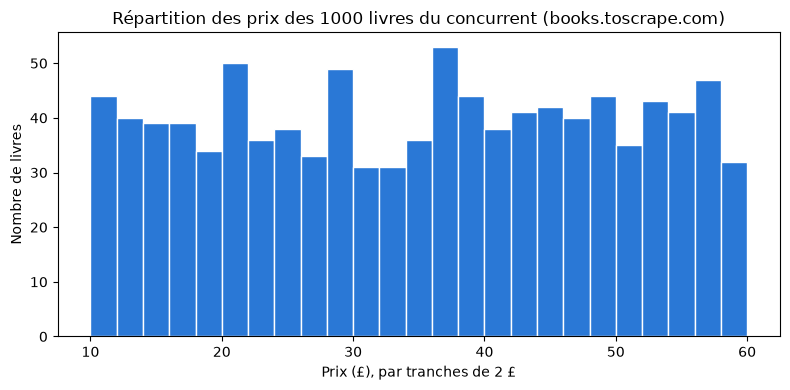

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
# bins = les bornes des tranches : 10, 12, 14, … 60 (range s'arrête avant 62)
ax.hist(catalogue["prix"], bins=range(10, 62, 2), color="#2a78d6", edgecolor="white")
ax.set_title(f"Répartition des prix des {len(catalogue)} livres du concurrent (books.toscrape.com)")
ax.set_xlabel("Prix (£), par tranches de 2 £")
ax.set_ylabel("Nombre de livres")
plt.tight_layout()
plt.show()

Les prix sont étalés **à peu près uniformément** entre 10 £ et 60 £ : chaque tranche compte entre 30 et 55 livres environ (40 en moyenne), aucune ne domine. C'est encore la signature d'un tirage au hasard ; un vrai catalogue aurait plutôt des prix concentrés autour de quelques valeurs.

## 9. La fragilité du scraping : détecter un changement du site

Une API est un **contrat** : son format est documenté et change rarement. Une page HTML, elle, est faite pour des **humains** : le site peut la redessiner du jour au lendemain, sans prévenir personne. Nos sélecteurs (`article.product_pod`, `p.price_color`…) cassent alors.

Le pire, c'est que cela peut casser **en silence**. Simulons un site qui renomme sa classe `product_pod` en `produit` :

In [35]:
html_modifie = reponse.text.replace("product_pod", "produit")

livres_casses = extraire_livres(html_modifie, URL_DEPART)
print("Livres extraits de la page modifiée :", len(livres_casses))

Livres extraits de la page modifiée : 0


**Zéro livre, et aucune erreur Python !** `select` a simplement renvoyé une liste vide. Sans contrôle, on enregistrerait un catalogue vide (ou incomplet) sans s'en rendre compte.

D'où un petit contrôle : chaque page de liste doit contenir **20 livres** ; sinon, on affiche un avertissement.

In [36]:
LIVRES_PAR_PAGE = 20

def verifier_page(livres_page, nom_page):
    """Renvoie True si la page contient le nombre de livres attendu, sinon avertit."""
    if len(livres_page) != LIVRES_PAR_PAGE:
        print(f"⚠️ {nom_page} : {len(livres_page)} livres au lieu de {LIVRES_PAR_PAGE} (HTML modifié ?)")
        return False
    return True

Appliquons-le à toutes les pages du cache (aucune requête : tout est sur le disque), puis à la page modifiée.

In [37]:
nb_anomalies = 0
for chemin in sorted(DOSSIER_CACHE.glob("page-*.html")):
    livres_page = extraire_livres(chemin.read_text(encoding="utf-8"), URL_DEPART)
    if not verifier_page(livres_page, chemin.name):
        nb_anomalies = nb_anomalies + 1
print("Pages en anomalie dans le cache :", nb_anomalies)

page_modifiee_ok = verifier_page(livres_casses, "page modifiée")
print("Page modifiée acceptée ?", page_modifiee_ok)

Pages en anomalie dans le cache : 0
⚠️ page modifiée : 0 livres au lieu de 20 (HTML modifié ?)
Page modifiée acceptée ? False


> 💡 Dans un vrai projet, on appelle ce contrôle **dans** la boucle de collecte, à chaque page, et on s'arrête (ou on alerte l'équipe) dès la première anomalie. On surveille aussi le nombre total de lignes et la part de valeurs manquantes d'une collecte à l'autre : le HTML change sans prévenir, il faut donc surveiller chaque collecte.
>
> ⚠️ Attention aux cas normaux : la **dernière** page d'une catégorie peut contenir moins de 20 livres (voir l'exercice 5).

## 10. Et si la page est construite en JavaScript ? Scrapy, Playwright, Selenium

`requests` récupère le HTML **envoyé par le serveur**. Sur books.toscrape.com, toutes les données y sont déjà : on parle de page **statique**. On peut le vérifier en cherchant dans `reponse.text` un titre visible à l'écran :

In [38]:
print("Le titre du 1er livre est-il dans le HTML reçu ?", "A Light in the Attic" in reponse.text)

Le titre du 1er livre est-il dans le HTML reçu ? True


Beaucoup de sites modernes envoient au contraire une page presque vide, que du code **JavaScript** remplit ensuite **dans le navigateur**. `requests` n'exécute pas le JavaScript : il ne verrait aucun livre. Le test ci-dessus répondrait `False`.

| Outil | Pour quoi faire | Remarques |
|---|---|---|
| `requests` + `BeautifulSoup` | pages **statiques**, quelques centaines de pages | ce notebook : simple et léger |
| **Scrapy** | collecter **à grande échelle** (des milliers de pages, plusieurs sites) | gère la file d'attente, les requêtes en parallèle, les pauses, `robots.txt`, les nouveaux essais, l'export |
| **Playwright**, **Selenium** | pages **rendues en JavaScript**, clics, défilement, formulaires | pilotent un vrai navigateur : beaucoup plus lents et gourmands |

> 💡 Avant de sortir Playwright, ouvrez l'outil de développement du navigateur (F12), onglet **Réseau** (*Network*), et rechargez la page. Souvent, le JavaScript va chercher ses données auprès d'une **API JSON interne** : l'appeler directement est plus simple et plus robuste. Retour à la règle d'or !

## 11. Exercices

Les solutions sont données sous chaque énoncé (cellules `# ✅ Solution`). Essayez d'abord par vous-même !

### ✍️ Exercice 1 — Combien de livres 5 étoiles ?

Le responsable veut savoir combien de livres du concurrent sont notés **5 étoiles**, et quelle part du catalogue cela représente (en pourcentage).

*Indice : filtrez `catalogue` sur la colonne `note`.*

In [39]:
# ✅ Solution
cinq_etoiles = catalogue[catalogue["note"] == 5]
part = len(cinq_etoiles) / len(catalogue)

print("Livres notés 5 étoiles :", len(cinq_etoiles))   # même chiffre que le tableau par_note (8.4)
print(f"Part du catalogue      : {part:.1%}")

Livres notés 5 étoiles : 196
Part du catalogue      : 19.6%


### ✍️ Exercice 2 — Une colonne booléenne `en_stock`

Une colonne **booléenne** ne contient que deux valeurs : `True` (vrai) ou `False` (faux). C'est plus pratique à filtrer et à compter qu'un texte.

1. Ajoutez au `catalogue` une colonne `en_stock` qui vaut `True` quand `disponibilite` est « In stock ».
2. Combien de livres sont en stock ? Que vous apprend cette colonne pour la veille de prix ?

In [40]:
# ✅ Solution
catalogue["en_stock"] = catalogue["disponibilite"] == "In stock"

print(catalogue["en_stock"].value_counts())
print("Livres en stock :", catalogue["en_stock"].sum(), "sur", len(catalogue))

en_stock
True    1000
Name: count, dtype: int64
Livres en stock : 1000 sur 1000


*Réponse* : **tous** les livres sont « In stock » sur les pages de liste. La colonne n'apporte donc aucune information ici ! La **quantité** exacte en stock ne figure que sur la fiche détaillée de chaque livre (exercice 4). Bon réflexe : vérifier qu'une colonne varie avant de s'en servir.

> 💡 `catalogue["en_stock"].sum()` compte les `True`, car Python les traite comme des 1.

### ✍️ Exercice 3 — Les plus chers sont-ils les mieux notés ?

1. Affichez les **10 livres les plus chers parmi ceux notés 5 étoiles** (titre et prix).
2. Calculez la **note moyenne** des 10 livres les plus chers du catalogue (tableau `dix_plus_chers` de la section 8.4) et comparez-la à la note moyenne de tout le catalogue. Conclusion ?

In [41]:
# ✅ Solution
# 1) Les 10 plus chers parmi les 5 étoiles
cinq_etoiles = catalogue[catalogue["note"] == 5]
print(cinq_etoiles.sort_values("prix", ascending=False).head(10)[["titre", "prix"]])

# 2) Note moyenne : les 10 plus chers contre tout le catalogue
print()
print("Note moyenne des 10 plus chers :", dix_plus_chers["note"].mean())
print("Note moyenne du catalogue      :", round(catalogue["note"].mean(), 2))

                                                 titre   prix
560                     The Barefoot Contessa Cookbook  59.92
812                              Life Without a Recipe  59.04
637     Approval Junkie: Adventures in Caring Too Much  58.81
379  How to Speak Golf: An Illustrated Guide to Lin...  58.32
631                                   Digital Fortress  58.00
545                                  The Sound Of Love  57.84
910         Travels with Charley: In Search of America  57.82
309                                           El Deafo  57.62
898                                      H is for Hawk  57.42
100  Immunity: How Elie Metchnikoff Changed the Cou...  57.36

Note moyenne des 10 plus chers : 2.8
Note moyenne du catalogue      : 2.92


*Réponse* : les 10 livres les plus chers ne sont **pas** mieux notés que la moyenne (ils le sont même un peu moins). Sur ce site, on ne voit aucun lien entre prix et note, ce qui confirme le bandeau : les deux sont tirés au hasard.

### ✍️ Exercice 4 — La fiche détaillée : catégorie, UPC et stock

Les pages de liste ne disent pas tout. La **fiche** d'un livre (son `url`) contient en plus :
- un **fil d'Ariane** (*breadcrumb*), la ligne `Home > Books > Catégorie` en haut de page : ce sont les liens `ul.breadcrumb li a` ;
- un **tableau** « Product Information » (`table tr`) : chaque ligne `<tr>` contient un nom dans `<th>` et une valeur dans `<td>`. On y trouve l'**UPC** (*Universal Product Code*, le code-barres du produit) et la quantité en stock.

Pour le livre **le plus cher** du catalogue, récupérez sa catégorie, son UPC et sa disponibilité détaillée. Utilisez `lire_page` pour profiter du cache et de la pause.

> 💡 Pourquoi l'UPC intéresse la librairie : pour comparer **ses** prix à ceux du concurrent, il faut retrouver les **mêmes** livres des deux côtés. Un identifiant comme l'UPC (ou l'ISBN) est bien plus fiable que le titre (souvenez-vous du titre en double).

In [42]:
# ✅ Solution
livre = catalogue.sort_values("prix", ascending=False).iloc[0]   # 1re ligne = le plus cher
print("Livre :", livre["titre"], "|", livre["prix"], "£")
print("Fiche :", livre["url"])

# Nom du fichier de cache tiré de l'URL : …/the-perfect-play-…_xxx/index.html → the-perfect-play-…_xxx
nom_fichier = livre["url"].split("/")[-2] + ".html"
html_fiche = lire_page(livre["url"], DOSSIER_CACHE / nom_fichier)
soupe_fiche = BeautifulSoup(html_fiche, "html.parser")

Livre : The Perfect Play (Play by Play #1) | 59.99 £
Fiche : https://books.toscrape.com/catalogue/the-perfect-play-play-by-play-1_352/index.html


Il reste à lire le fil d'Ariane et le tableau de la fiche :

In [43]:
# ✅ Solution (suite)
# Fil d'Ariane : Home > Books > <catégorie>  → 3e lien (indice 2)
liens_ariane = soupe_fiche.select("ul.breadcrumb li a")
categorie = liens_ariane[2].get_text(strip=True)

# Tableau : on range chaque ligne <th> → <td> dans un dictionnaire
infos = {}
for ligne in soupe_fiche.select("table tr"):
    infos[ligne.th.get_text(strip=True)] = ligne.td.get_text(strip=True)

print("Catégorie     :", categorie)
print("UPC           :", infos["UPC"])
print("Disponibilité :", infos["Availability"])

Catégorie     : Romance
UPC           : 9cc207168a03470d
Disponibilité : In stock (4 available)


### ✍️ Exercice 5 — Scraper une seule catégorie : Travel

La librairie se spécialise dans les **livres de voyage**. Récupérez uniquement la catégorie **Travel** du concurrent.

1. Dans le menu de gauche de la page 1 (`div.side_categories ul li ul li a`), trouvez le lien dont le texte est « Travel » et calculez son adresse absolue avec `urljoin`.
2. Réutilisez `scraper_catalogue` avec un **dossier de cache à part** (sinon les fichiers `page-1.html` se mélangeraient avec ceux du catalogue).
3. Combien de livres ? Sont-ils tous présents dans `catalogue` (comparez les URL) ? Leur prix moyen est-il différent de celui du catalogue ?

*Bonus* : faites de même avec « Mystery » (32 livres sur 2 pages) pour vérifier que la pagination s'arrête toute seule.

In [44]:
# ✅ Solution
# 1) Le lien « Travel » dans le menu de la page 1 (déjà en cache : aucune requête)
html_page_1 = lire_page(URL_DEPART, DOSSIER_CACHE / "page-1.html")
soupe_menu = BeautifulSoup(html_page_1, "html.parser")

url_travel = None
for lien_categorie in soupe_menu.select("div.side_categories ul li ul li a"):
    if lien_categorie.get_text(strip=True) == "Travel":
        url_travel = urljoin(URL_DEPART, lien_categorie["href"])
print("Adresse de la catégorie :", url_travel)

Adresse de la catégorie : https://books.toscrape.com/catalogue/category/books/travel_2/index.html


On réutilise ensuite la fonction de pagination telle quelle, avec un autre dossier de cache :

In [45]:
# ✅ Solution (suite)
# 2) Même fonction de pagination, autre dossier de cache
dossier_travel = DOSSIER_DATA / "raw" / "scraping" / "books_travel" / AUJOURDHUI
travel = pd.DataFrame(scraper_catalogue(url_travel, dossier_travel, MAX_PAGES))

# 3) Contrôles et comparaison
print("Livres dans Travel             :", len(travel))
print("Tous présents dans le catalogue :", travel["url"].isin(catalogue["url"]).all())
print(f"Prix moyen Travel    : {travel['prix'].mean():.2f} £")
print(f"Prix moyen catalogue : {catalogue['prix'].mean():.2f} £")

Livres dans Travel             : 11
Tous présents dans le catalogue : True
Prix moyen Travel    : 39.79 £
Prix moyen catalogue : 35.07 £


*Réponse* : 11 livres, tous déjà présents dans notre catalogue complet (ouf, nos deux collectes sont cohérentes). Leur prix moyen (environ 39,8 £) dépasse celui du catalogue (35,1 £), mais sur 11 livres seulement, l'écart peut être dû au hasard : prudence avant d'en tirer une règle. Une seule page : il n'y a pas de bouton « next », la boucle s'arrête après le premier tour. Notez que `verifier_page` aurait signalé 11 livres au lieu de 20 : c'est ici un cas **normal** (dernière page).

## Récapitulatif

**Ce que vous avez fait**
- vérifié **avant** de collecter : règle d'or (API > fichier officiel > scraping), `robots.txt` (absent : 404), bandeau du site, finalité et minimisation ;
- téléchargé une page avec `requests` et corrigé l'encodage (« Â£ » → « £ ») ;
- lu la structure HTML d'un livre et extrait titre, prix, note et disponibilité avec BeautifulSoup ;
- parcouru les 50 pages en suivant le lien « next », avec User-Agent, pauses et **cache** daté sur disque ;
- livré le catalogue complet de 1 000 livres en CSV et Parquet, après contrôles (compte, doublons, valeurs manquantes) ;
- répondu à la librairie : sur ce site, la note n'influence pas le prix.

**Les réflexes à retenir**
- le scraping est le **dernier recours** : cherchez d'abord une API ou un fichier ;
- lisez `robots.txt` **et** les CGU ; ne collectez que le nécessaire, et méfiez-vous des données personnelles ;
- soyez poli : **User-Agent** explicite, **`timeout`**, **pause** entre les pages, **cache** pour ne jamais télécharger deux fois ;
- vérifiez l'**encodage** dès que des caractères bizarres apparaissent (`reponse.encoding = "utf-8"`) ;
- préférez les **attributs** (`title`, `href`) au texte affiché, souvent tronqué, et `urljoin` pour les liens relatifs ;
- **contrôlez** chaque collecte (nombre de lignes attendu, doublons sur un vrai identifiant, valeurs manquantes) : un scraper casse souvent **en silence**.

## Pour aller plus loin

- **Lire `robots.txt` automatiquement** : le module `urllib.robotparser` de la bibliothèque standard répond à la question « ai-je le droit de visiter cette adresse ? » (`can_fetch(user_agent, url)`).
- **Ne retélécharger que ce qui a changé** : l'en-tête `Last-Modified` vu à la section 3 (ou son cousin `ETag`, une empreinte de la page) permet d'envoyer une requête **conditionnelle** (`If-Modified-Since`) ; si rien n'a changé, le serveur répond **304 Not Modified**, sans renvoyer la page.
- **Une vraie veille de prix** : planifiez la collecte chaque jour, puis comparez le Parquet du jour à celui de la veille (jointure sur `url` avec `pd.merge`) pour lister les livres dont le prix a bougé. DuckDB peut interroger tous les fichiers datés d'un coup.
- **Scrapy** : son tutoriel officiel s'entraîne justement sur les sites `toscrape.com` (https://docs.scrapy.org/en/latest/intro/tutorial.html).